In [18]:
import numpy as np
import pandas as pd
import pickle

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

In [19]:
with open("../models/preprocessor.pkl", "rb") as f:
    preprocessor = pickle.load(f)

with open("../models/feature_order.pkl", "rb") as f:
    feature_order = pickle.load(f)

num_features = feature_order["numeric"]
cat_features = feature_order["categorical"]

In [20]:
df = pd.read_csv("../data/raw/housing.csv")

In [21]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

for col in ["total_rooms", "total_bedrooms", "population", "households", "median_income"]:
    df[f"{col}_log1p"] = np.log1p(df[col])

df = df.drop(columns=["total_rooms", "total_bedrooms", "population", "households", "median_income"])

In [22]:
target = "median_house_value"

X = df.drop(columns=[target])

y_log = np.log1p(df[target])

y_mean = y_log.mean()
y_std  = y_log.std()
y = (y_log - y_mean) / y_std

print("y mean (log):", y_mean, "y std (log):", y_std)

y mean (log): 12.084890845009992 y std (log): 0.5691306068427147


In [23]:
X_proc = preprocessor.transform(X)

print("X_proc shape:", X_proc.shape)
print("Max abs value (sanity):", np.max(np.abs(X_proc)))

X_proc shape: (20640, 15)
Max abs value (sanity): 82.19620150129612


In [24]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_proc, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(14448, 15) (3096, 15) (3096, 15)


In [25]:
ones_X = np.ones((X_train.shape[0], 1))
ones_X_val = np.ones((X_val.shape[0], 1))
ones_X_test = np.ones((X_test.shape[0], 1))

X_train_bias = np.c_[ones_X, X_train]
X_val_bias = np.c_[ones_X_val, X_val]
X_test_bias = np.c_[ones_X_test, X_test]

In [26]:
n = X_train_bias.shape[1]
theta = np.zeros(n)

alpha = 0.0005
iterations = 4000   

lmbd = 0.3

In [27]:
def predict(X, theta):
    return X @ theta

def compute_cost_ridge(X, y, theta, lmbd):
    m = len(y)
    preds = predict(X, theta)
    errors = preds - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    # not considering bias theta 0
    reg = (lmbd / (2 * m)) * np.sum(theta[1:] ** 2)
    return cost + reg

In [28]:
def compute_gradient_ridge(X, y, theta, lmbd):
    m = len(y)
    predictions = predict(X, theta)
    errors = predictions - y
    grad = (1 / m) * (X.T @ errors)
    # not considering bias theta 0
    reg = np.concatenate(([0.0], (lmbd / m) * theta[1:]))
    return grad + reg
    
def gradient_descent_ridge(X, y, theta, alpha, iterations, lmbd):
    cost_history = []
    
    for i in range(iterations):
        gradient = compute_gradient_ridge(X, y, theta, lmbd)
        
        theta = theta - alpha * gradient
        cost = compute_cost_ridge(X, y, theta, lmbd)
        
        cost_history.append(cost)
        
        if (i % 200) == 0:
            print(f"Iter {i} | cost --> {cost}")
            
    return theta, cost_history

In [29]:
theta_ridge, cost_hist = gradient_descent_ridge(
    X_train_bias, 
    y_train, 
    theta,
    alpha, 
    iterations, 
    lmbd
)

Iter 0 | cost --> 0.4995653557366554
Iter 200 | cost --> 0.43572062019067404
Iter 400 | cost --> 0.3890095687631998
Iter 600 | cost --> 0.35350149840835055
Iter 800 | cost --> 0.3256514924520131
Iter 1000 | cost --> 0.30325552463269223
Iter 1200 | cost --> 0.2848862232238167
Iter 1400 | cost --> 0.2695813136093674
Iter 1600 | cost --> 0.25666721791628944
Iter 1800 | cost --> 0.24565634462844593
Iter 2000 | cost --> 0.23618541487449582
Iter 2200 | cost --> 0.22797718547807208
Iter 2400 | cost --> 0.22081586401220027
Iter 2600 | cost --> 0.21453076883874225
Iter 2800 | cost --> 0.20898510865092174
Iter 3000 | cost --> 0.20406804393336292
Iter 3200 | cost --> 0.1996889208080124
Iter 3400 | cost --> 0.19577298790486308
Iter 3600 | cost --> 0.19225815496243287
Iter 3800 | cost --> 0.1890925020069868


In [30]:
y_train_pred = predict(X_train_bias, theta_ridge)
y_val_pred   = predict(X_val_bias, theta_ridge)

In [31]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

train_rmse_scaled = rmse(y_train, y_train_pred)
val_rmse_scaled   = rmse(y_val, y_val_pred)

print("Train RMSE (scaled):", train_rmse_scaled)
print("Val RMSE (scaled):", val_rmse_scaled)

Train RMSE (scaled): 0.6103132199651474
Val RMSE (scaled): 0.6292093767290204


In [32]:
y_train_pred_real = np.expm1(y_train_pred * y_std + y_mean)
y_train_real      = np.expm1(y_train * y_std + y_mean)

y_val_pred_real = np.expm1(y_val_pred * y_std + y_mean)
y_val_real      = np.expm1(y_val * y_std + y_mean)

In [33]:
train_rmse_real = rmse(y_train_real, y_train_pred_real)
val_rmse_real   = rmse(y_val_real, y_val_pred_real)

print("Train RMSE (real):", train_rmse_real)
print("Val RMSE (real):", val_rmse_real)

Train RMSE (real): 75817.41260758118
Val RMSE (real): 76839.64927760191


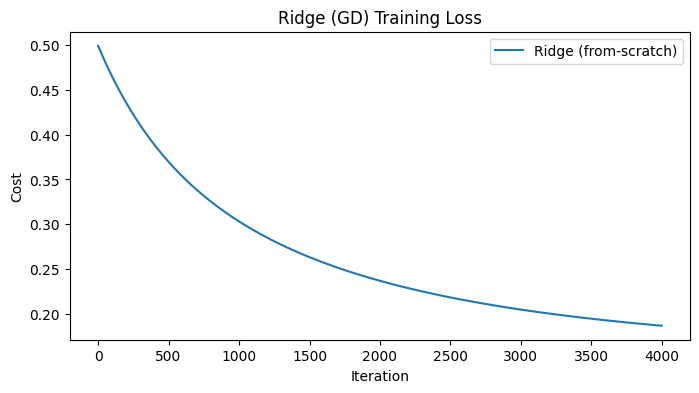

In [66]:
plt.figure(figsize=(8,4))
plt.plot(cost_hist, label='Ridge (from-scratch)')
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Ridge (GD) Training Loss")
plt.legend()
plt.show()

In [34]:
from sklearn.linear_model import Ridge

clf = Ridge(alpha=lmbd, random_state=42, solver='auto')
clf.fit(X_train, (y_train))
sk_pred_val = clf.predict(X_val)

print("Sklearn Ridge RMSE (scaled) on val:", rmse(y_val, sk_pred_val))

sk_pred_val_real = np.expm1(sk_pred_val * y_std + y_mean)
print("Sklearn Ridge RMSE (real) on val:", np.sqrt(mean_squared_error(y_val_real, sk_pred_val_real)))

Sklearn Ridge RMSE (scaled) on val: 0.5680937088635266
Sklearn Ridge RMSE (real) on val: 69135.50437610531


In [35]:
# bias term
feature_names = ["bias"]

# numeric features (already saved)
feature_names += num_features

# categorical features expanded by one-hot encoding
# ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
# cat_feature_names = ohe.get_feature_names_out(feature_order["categorical"])

# feature_names += list(cat_feature_names)

for name, value in zip(feature_names, theta_ridge):
    print(name, ":", value)

bias : 0.003625617596809701
longitude : -0.11591397880066709
latitude : -0.14827473382939044
housing_median_age : 0.11003354254265638
rooms_per_household : 0.014881972841291731
bedrooms_per_room : 0.022020670086759557
total_rooms_log1p : 0.05933386626797657
total_bedrooms_log1p : 0.041512537574036175
population_log1p : -0.08410512322071503
households_log1p : 0.063014407862555
median_income_log1p : 0.5276206240254444


In [38]:
np.save("../models/theta_ridge.npy", theta_ridge)
np.save("../models/ridge_cost_history.npy", np.array(cost_hist))

with open("../models/sklearn_ridge.pkl", "wb") as f:
    pickle.dump(
        {clf},f
    )